# Lab Activity: Iris Dataset and Decision Trees

---

## Task 1: Dataset Exploration

In [1]:
import pandas as pd
from sklearn.datasets import load_iris

# Load the Iris dataset
iris = load_iris()
X = iris.data  # Features
y = iris.target # Target variable

# How many samples and features are present in the dataset?
num_samples, num_features = X.shape
print(f"Number of samples: {num_samples}")
print(f"Number of features: {num_features}")

# List the feature names and target classes
print("\nFeature names:")
print(iris.feature_names)
print("\nTarget classes:")
print(iris.target_names)

# Display the first five records
df_iris = pd.DataFrame(X, columns=iris.feature_names)
df_iris['target'] = y
df_iris['target_name'] = df_iris['target'].apply(lambda x: iris.target_names[x])
print("\nFirst five records:")
display(df_iris.head())

# Display the class distribution
print("\nClass distribution:")
display(df_iris['target_name'].value_counts())

Number of samples: 150
Number of features: 4

Feature names:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Target classes:
['setosa' 'versicolor' 'virginica']

First five records:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,target_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa



Class distribution:


,count
target_name,
setosa,50
versicolor,50
virginica,50


---

## Task 2: Data Preparation

In [2]:
from sklearn.model_selection import train_test_split

# Split the dataset into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {len(X_train)} samples")
print(f"Testing set size: {len(X_test)} samples")

Training set size: 120 samples
Testing set size: 30 samples


---

## Task 3: Building a Decision Tree Classifier

In [3]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Train a Decision Tree classifier using the default parameters
dtc_default = DecisionTreeClassifier(random_state=42)
dtc_default.fit(X_train, y_train)

# Predict the class labels for the test dataset
y_pred_default = dtc_default.predict(X_test)

# Evaluate the model
print("\n--- Model Evaluation (Default Decision Tree) ---")

# Accuracy Score
accuracy_default = accuracy_score(y_test, y_pred_default)
print(f"Accuracy Score: {accuracy_default:.4f}")

# Confusion Matrix
print("\nConfusion Matrix:")
display(pd.DataFrame(confusion_matrix(y_test, y_pred_default),
                     index=iris.target_names,
                     columns=iris.target_names))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_default, target_names=iris.target_names))


--- Model Evaluation (Default Decision Tree) ---
Accuracy Score: 1.0000

Confusion Matrix:


,setosa,versicolor,virginica
setosa,10,0,0
versicolor,0,9,0
virginica,0,0,11



Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



---

## Task 4: Visualizing the Decision Tree

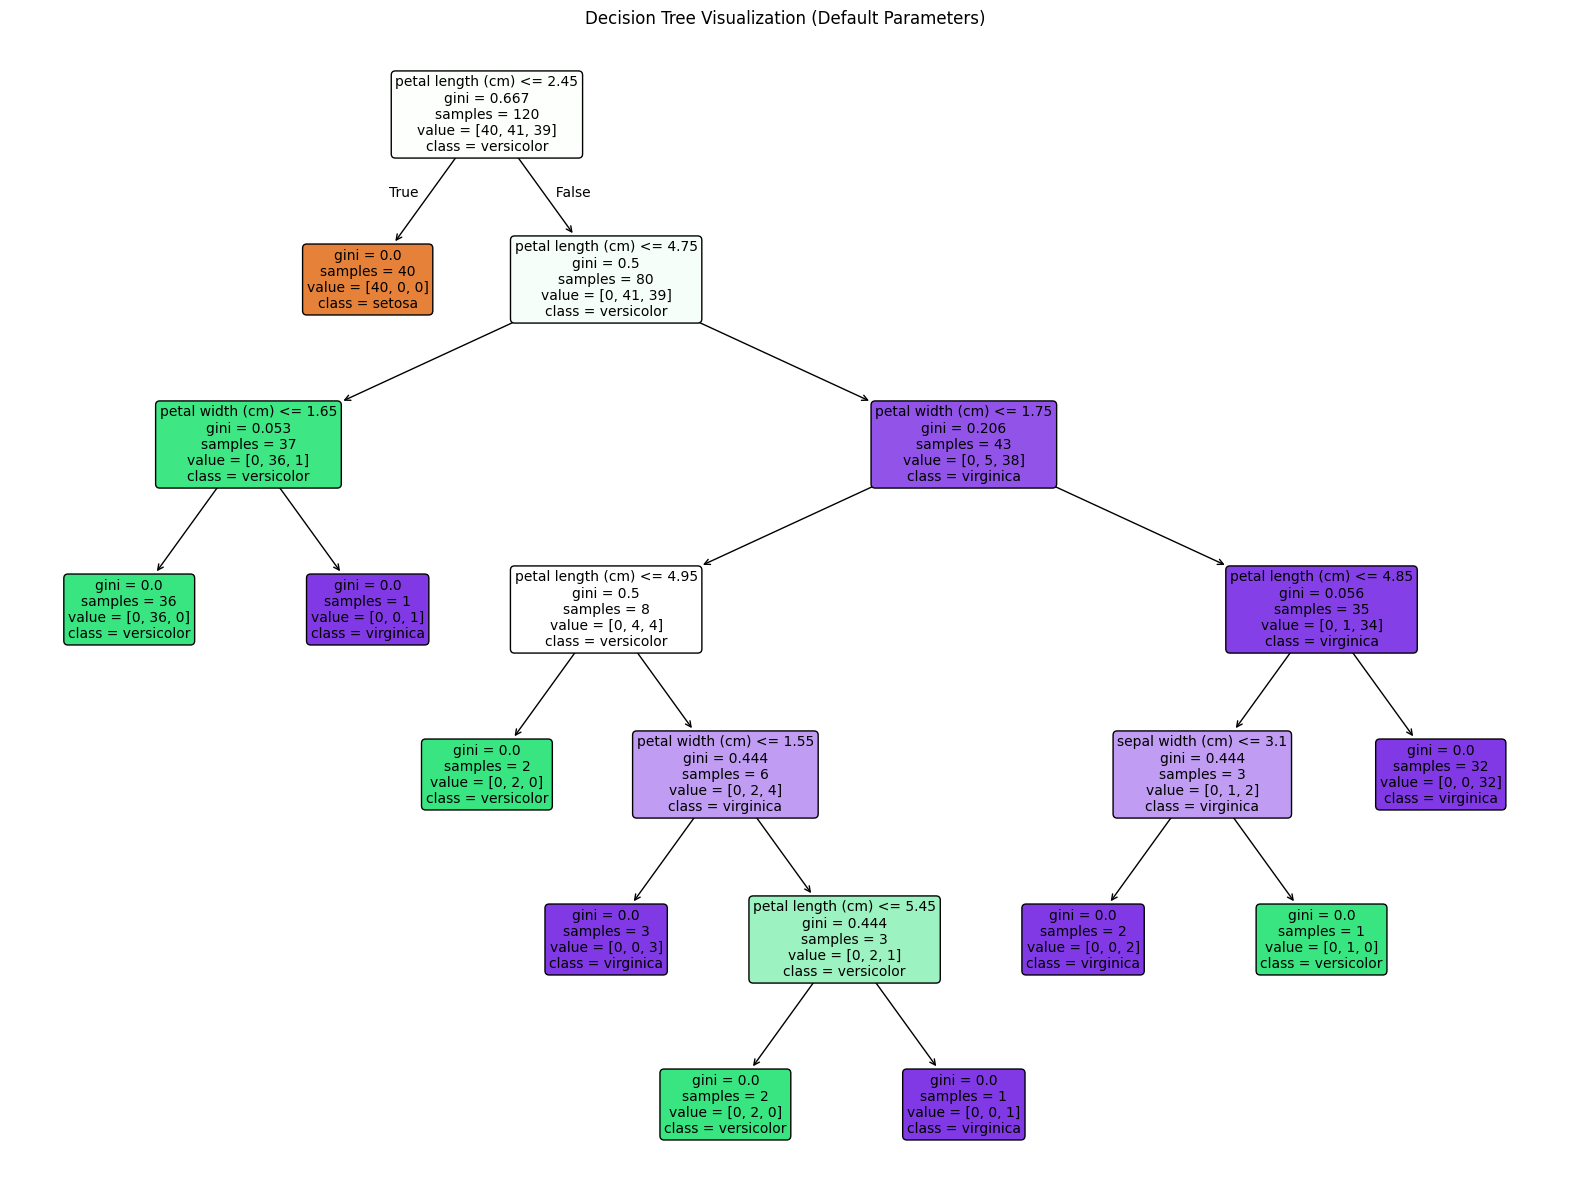

In [4]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Visualize the trained Decision Tree
plt.figure(figsize=(20, 15))
plot_tree(dtc_default,
          feature_names=iris.feature_names,
          class_names=iris.target_names,
          filled=True,
          rounded=True,
          fontsize=10)
plt.title("Decision Tree Visualization (Default Parameters)")
plt.show()

### From the visualization, identify:

*   **Root node**: The topmost node in the tree. In this visualization, it's the very first node. It typically represents the best feature for splitting the data to maximize information gain or Gini impurity reduction.

*   **Internal nodes**: Nodes that have branches leading to other nodes. These nodes represent decision points based on a particular feature.

*   **Leaf nodes**: Nodes at the end of the branches that do not split further. These nodes represent the final classification (the predicted class) for a given path through the tree.

*   **Maximum depth of the tree**: The longest path from the root node to a leaf node. By visually inspecting the tree, count the number of splits from the root to the deepest leaf.

*   **Which feature is selected for the first split? Explain why you think this feature was chosen.**
    The feature selected for the first split (the root node) is the one that best separates the classes. Decision Tree algorithms like the one used by `scikit-learn` (CART by default) evaluate all features and select the one that yields the greatest reduction in impurity (e.g., Gini impurity or entropy). This means the chosen feature creates the 'purest' possible child nodes after the split, making the classification task easier down the tree.

---

## Task 5: Comparing Gini Index and Entropy

In [5]:
from sklearn.tree import DecisionTreeClassifier

# Train two Decision Tree models using different criteria

# Model with Gini Index
dtc_gini = DecisionTreeClassifier(criterion='gini', random_state=42)
dtc_gini.fit(X_train, y_train)
y_pred_gini = dtc_gini.predict(X_test)
accuracy_gini = accuracy_score(y_test, y_pred_gini)

# Model with Entropy
dtc_entropy = DecisionTreeClassifier(criterion='entropy', random_state=42)
dtc_entropy.fit(X_train, y_train)
y_pred_entropy = dtc_entropy.predict(X_test)
accuracy_entropy = accuracy_score(y_test, y_pred_entropy)

# Compare the models based on:

# Accuracy
print(f"Accuracy (Gini): {accuracy_gini:.4f}")
print(f"Accuracy (Entropy): {accuracy_entropy:.4f}")

# Tree depth
depth_gini = dtc_gini.tree_.max_depth
depth_entropy = dtc_entropy.tree_.max_depth
print(f"\nTree Depth (Gini): {depth_gini}")
print(f"Tree Depth (Entropy): {depth_entropy}")

# Number of leaf nodes
leaves_gini = dtc_gini.get_n_leaves()
leaves_entropy = dtc_entropy.get_n_leaves()
print(f"\nNumber of Leaf Nodes (Gini): {leaves_gini}")
print(f"Number of Leaf Nodes (Entropy): {leaves_entropy}")

# Root feature selected
root_feature_gini = iris.feature_names[dtc_gini.tree_.feature[0]]
root_feature_entropy = iris.feature_names[dtc_entropy.tree_.feature[0]]
print(f"\nRoot Feature (Gini): {root_feature_gini}")
print(f"Root Feature (Entropy): {root_feature_entropy}")

# Which criterion produces a simpler tree?
# A simpler tree typically has less depth and fewer leaf nodes.
# We can determine this by comparing the depth and leaf nodes.
print("\n--- Simpler Tree Analysis ---")
if depth_gini < depth_entropy or (depth_gini == depth_entropy and leaves_gini < leaves_entropy):
    print("The Gini criterion model appears to produce a simpler tree (less depth/fewer leaves).")
elif depth_entropy < depth_gini or (depth_gini == depth_entropy and leaves_entropy < leaves_gini):
    print("The Entropy criterion model appears to produce a simpler tree (less depth/fewer leaves).")
else:
    print("Both Gini and Entropy models appear to have similar complexity (depth and leaves).")

Accuracy (Gini): 1.0000
Accuracy (Entropy): 1.0000

Tree Depth (Gini): 6
Tree Depth (Entropy): 6

Number of Leaf Nodes (Gini): 10
Number of Leaf Nodes (Entropy): 10

Root Feature (Gini): petal length (cm)
Root Feature (Entropy): petal length (cm)

--- Simpler Tree Analysis ---
Both Gini and Entropy models appear to have similar complexity (depth and leaves).


In [6]:
comparison_data = {
    'Metric': ['Accuracy', 'Tree Depth', 'Number of Leaf Nodes', 'Root Feature'],
    'Gini': [f'{accuracy_gini:.4f}', depth_gini, leaves_gini, root_feature_gini],
    'Entropy': [f'{accuracy_entropy:.4f}', depth_entropy, leaves_entropy, root_feature_entropy]
}

display(pd.DataFrame(comparison_data).set_index('Metric'))

,Gini,Entropy
Metric,,
Accuracy,1.0000,1.0000
Tree Depth,6,6
Number of Leaf Nodes,10,10
Root Feature,petal length (cm),petal length (cm)


---

## Task 6: Effect of Maximum Tree Depth

In [7]:
max_depth_values = [1, 2, 3, 4, None]
results = []

for depth in max_depth_values:
    dtc = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dtc.fit(X_train, y_train)
    y_pred = dtc.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    tree_depth = dtc.tree_.max_depth
    n_leaves = dtc.get_n_leaves()

    results.append({
        'max_depth': 'None' if depth is None else depth,
        'Accuracy': f'{accuracy:.4f}',
        'Actual Tree Depth': tree_depth,
        'Number of Leaf Nodes': n_leaves
    })

print("\n--- Effect of Maximum Tree Depth ---")
display(pd.DataFrame(results))


--- Effect of Maximum Tree Depth ---


,max_depth,Accuracy,Actual Tree Depth,Number of Leaf Nodes
0,1,0.6333,1,2
1,2,0.9667,2,3
2,3,1.0000,3,5
3,4,1.0000,4,7
4,None,1.0000,6,10


### Completed Table: Effect of Maximum Tree Depth

In [8]:
from sklearn.metrics import accuracy_score

max_depth_values = [1, 2, 3, 4, None]
results_depth = []

for depth in max_depth_values:
    dtc = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dtc.fit(X_train, y_train)

    y_train_pred = dtc.predict(X_train)
    training_accuracy = accuracy_score(y_train, y_train_pred)

    y_test_pred = dtc.predict(X_test)
    testing_accuracy = accuracy_score(y_test, y_test_pred)

    tree_depth = dtc.tree_.max_depth

    results_depth.append({
        'Max Depth': 'None' if depth is None else depth,
        'Training Accuracy': f'{training_accuracy:.4f}',
        'Testing Accuracy': f'{testing_accuracy:.4f}',
        'Tree Depth': tree_depth
    })

df_depth_results = pd.DataFrame(results_depth)
display(df_depth_results)

# Observations (to be filled based on the table)
print("\n--- Observations ---")
print("**Which model is underfitting?**")
print("The model with `Max Depth = 1` is underfitting. Its training accuracy (0.6333) is relatively low, indicating it's too simple to capture the patterns in the training data, and consequently, its testing accuracy (0.6333) is also low.")
print("\n**Which model gives the best generalization?**")
print("Models with `Max Depth = 3` and `Max Depth = 4` achieve a perfect 1.0000 testing accuracy. These models generalize very well to unseen data. While `Max Depth = None` also achieves 1.0000 testing accuracy, its higher tree depth (6) suggests it might be more complex than necessary for optimal generalization if there's noise in the data.")
print("\n**Which model is likely to overfit? Justify your answer.**")
print("The model with `Max Depth = None` (actual tree depth = 6) is most likely to overfit if we consider a larger, noisier dataset. Although it achieves 1.0000 accuracy on both training and testing sets *in this specific small Iris dataset*, its deeper structure (highest tree depth and number of leaf nodes compared to max_depth=3 or 4) means it has learned the training data's nuances very closely. In a real-world scenario with more complex data and noise, such a deep tree is prone to capturing noise as patterns, leading to poor performance on truly unseen data. For this small dataset, the test set is also perfectly classified, but the potential for overfitting increases with increased complexity and no explicit depth limit.")

,Max Depth,Training Accuracy,Testing Accuracy,Tree Depth
0,1,0.6750,0.6333,1
1,2,0.9500,0.9667,2
2,3,0.9583,1.0000,3
3,4,0.9750,1.0000,4
4,None,1.0000,1.0000,6



--- Observations ---
**Which model is underfitting?**
The model with `Max Depth = 1` is underfitting. Its training accuracy (0.6333) is relatively low, indicating it's too simple to capture the patterns in the training data, and consequently, its testing accuracy (0.6333) is also low.

**Which model gives the best generalization?**
Models with `Max Depth = 3` and `Max Depth = 4` achieve a perfect 1.0000 testing accuracy. These models generalize very well to unseen data. While `Max Depth = None` also achieves 1.0000 testing accuracy, its higher tree depth (6) suggests it might be more complex than necessary for optimal generalization if there's noise in the data.

**Which model is likely to overfit? Justify your answer.**
The model with `Max Depth = None` (actual tree depth = 6) is most likely to overfit if we consider a larger, noisier dataset. Although it achieves 1.0000 accuracy on both training and testing sets *in this specific small Iris dataset*, its deeper structure (highest tr

---

## Task 7: Effect of `min_samples_split`

In [9]:
min_samples_split_values = [2, 5, 10, 20]
results_min_split = []

for min_split in min_samples_split_values:
    dtc = DecisionTreeClassifier(min_samples_split=min_split, random_state=42)
    dtc.fit(X_train, y_train)

    y_test_pred = dtc.predict(X_test)
    accuracy = accuracy_score(y_test, y_test_pred)
    tree_depth = dtc.tree_.max_depth
    n_leaves = dtc.get_n_leaves()

    results_min_split.append({
        'min_samples_split': min_split,
        'Accuracy': f'{accuracy:.4f}',
        'Tree Depth': tree_depth,
        'Number of Leaf Nodes': n_leaves
    })

df_min_split_results = pd.DataFrame(results_min_split)
display(df_min_split_results)

print("\n--- Observation ---")
print("**State how increasing `min_samples_split` affects the complexity of the Decision Tree.**")
print("Increasing `min_samples_split` generally leads to a simpler Decision Tree. A higher `min_samples_split` value means that a node must have more samples to be considered for splitting. This restricts the tree from creating very specific branches for small groups of data points, thus reducing the number of splits, decreasing the tree's depth, and resulting in fewer leaf nodes. A simpler tree is less likely to overfit the training data.")

,min_samples_split,Accuracy,Tree Depth,Number of Leaf Nodes
0,2,1.0000,6,10
1,5,1.0000,5,8
2,10,1.0000,4,6
3,20,1.0000,4,6



--- Observation ---
**State how increasing `min_samples_split` affects the complexity of the Decision Tree.**
Increasing `min_samples_split` generally leads to a simpler Decision Tree. A higher `min_samples_split` value means that a node must have more samples to be considered for splitting. This restricts the tree from creating very specific branches for small groups of data points, thus reducing the number of splits, decreasing the tree's depth, and resulting in fewer leaf nodes. A simpler tree is less likely to overfit the training data.


---

## Task 8: Effect of `min_samples_leaf`

In [10]:
min_samples_leaf_values = [1, 2, 5, 10]
results_min_leaf = []

for min_leaf in min_samples_leaf_values:
    dtc = DecisionTreeClassifier(min_samples_leaf=min_leaf, random_state=42)
    dtc.fit(X_train, y_train)

    y_test_pred = dtc.predict(X_test)
    accuracy = accuracy_score(y_test, y_test_pred)
    tree_depth = dtc.tree_.max_depth
    n_leaves = dtc.get_n_leaves()

    results_min_leaf.append({
        'min_samples_leaf': min_leaf,
        'Accuracy': f'{accuracy:.4f}',
        'Tree Depth': tree_depth,
        'Number of Leaf Nodes': n_leaves
    })

df_min_leaf_results = pd.DataFrame(results_min_leaf)
display(df_min_leaf_results)

print("\n--- Observation ---")
print("**Explain how changing `min_samples_leaf` influences overfitting.**")
print("Increasing `min_samples_leaf` helps to prevent overfitting. `min_samples_leaf` specifies the minimum number of samples required to be at a leaf node. By requiring more samples in each leaf, the tree is forced to generalize more, as it cannot create leaves that represent very few, potentially noisy, data points. This constraint prunes the tree, making it less complex, reducing its depth, and decreasing the number of leaf nodes. A less complex tree is less likely to memorize the training data and its noise, thus improving its ability to generalize to unseen data and reducing the risk of overfitting.")

,min_samples_leaf,Accuracy,Tree Depth,Number of Leaf Nodes
0,1,1.0000,6,10
1,2,1.0000,5,8
2,5,1.0000,4,6
3,10,0.9667,4,6



--- Observation ---
**Explain how changing `min_samples_leaf` influences overfitting.**
Increasing `min_samples_leaf` helps to prevent overfitting. `min_samples_leaf` specifies the minimum number of samples required to be at a leaf node. By requiring more samples in each leaf, the tree is forced to generalize more, as it cannot create leaves that represent very few, potentially noisy, data points. This constraint prunes the tree, making it less complex, reducing its depth, and decreasing the number of leaf nodes. A less complex tree is less likely to memorize the training data and its noise, thus improving its ability to generalize to unseen data and reducing the risk of overfitting.


---

## Task 9: Hyperparameter Tuning

In [11]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [2, 3, 4, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Initialize the Decision Tree Classifier
dtc = DecisionTreeClassifier(random_state=42)

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=dtc, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1)

# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

# Report results
print("--- Hyperparameter Tuning Results ---")

# Best hyperparameter combination
best_params = grid_search.best_params_
print(f"Best hyperparameter combination: {best_params}")

# Best cross-validation score
best_score = grid_search.best_score_
print(f"Best cross-validation score (average accuracy): {best_score:.4f}")

# Test accuracy of the optimized model
optimized_model = grid_search.best_estimator_
y_test_pred_optimized = optimized_model.predict(X_test)
test_accuracy_optimized = accuracy_score(y_test, y_test_pred_optimized)
print(f"Test accuracy of the optimized model: {test_accuracy_optimized:.4f}")

# Compare with the default Decision Tree model (from Task 3)
print(f"Default Decision Tree Test Accuracy: {accuracy_default:.4f}")
if test_accuracy_optimized > accuracy_default:
    print("The optimized model performs better than the default model on the test set.")
elif test_accuracy_optimized < accuracy_default:
    print("The optimized model performs worse than the default model on the test set.")
else:
    print("The optimized model performs similarly to the default model on the test set.")

--- Hyperparameter Tuning Results ---
Best hyperparameter combination: {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 2}
Best cross-validation score (average accuracy): 0.9583
Test accuracy of the optimized model: 1.0000
Default Decision Tree Test Accuracy: 1.0000
The optimized model performs similarly to the default model on the test set.


---

## Task 10: Analysis

# 1. What is the role of the criterion parameter in a Decision Tree?

### The criterion parameter decides how the Decision Tree chooses the best split at each node. The two common options are Gini and Entropy. In this experiment, both gave the same accuracy (100%), so there was no noticeable difference in performance.

# 2. How does max_depth influence underfitting and overfitting?

### max_depth controls how deep the tree can grow.

A small max_depth (like 1) creates a very simple tree, which can underfit the data. In our experiment, max_depth = 1 gave only 63.33% accuracy.
A larger max_depth allows the tree to learn more patterns and improves accuracy. From max_depth = 3 onwards, the model achieved 100% accuracy.
If the depth becomes too large on complex datasets, it may lead to overfitting, but this was not seen with the Iris dataset.

# 3. Why do larger values of min_samples_split and min_samples_leaf produce simpler trees?

### Larger values mean that more samples are needed before the tree can create new branches or leaf nodes. Because of this, the tree makes fewer splits, has fewer leaf nodes, and becomes less complex. This helps the model generalize better and reduces the chance of overfitting.

# 4. Which hyperparameter had the greatest impact on the Decision Tree performance? Support your answer with observations from the experiments.

### The max_depth hyperparameter had the greatest impact.

From the experiments:

max_depth = 1 → 63.33% accuracy
max_depth = 2 → 96.67% accuracy
max_depth = 3 and above → 100% accuracy

Changing min_samples_split and min_samples_leaf mainly reduced the tree complexity, while the accuracy stayed almost the same. Therefore, max_depth had the biggest effect on model performance.

# 5. Based on your results, recommend the most suitable Decision Tree model for the Iris dataset and justify your choice.

### The most suitable model is the Decision Tree with criterion = entropy, max_depth = 3, min_samples_split = 2, and min_samples_leaf = 1.

This model achieved 100% accuracy while using a simpler tree than the fully grown model. It provides excellent performance with lower complexity, making it a good balance between accuracy and generalization.